###**Climate Change Impact on Agriculture Analysis**

This project analyzes the Climate Change Impact on Agriculture dataset. The objective is to explore the dataset, preprocess the data, handle missing values, perform feature engineering, visualize relationships using Seaborn, scale numerical features, encode categorical variables, and derive meaningful sustainability insights.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv("climate_change_impact_on_agriculture_2024.csv")

df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


In [3]:
print(df.shape)

(10000, 15)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         10000 non-null  int64  
 1   Country                      10000 non-null  object 
 2   Region                       10000 non-null  object 
 3   Crop_Type                    10000 non-null  object 
 4   Average_Temperature_C        10000 non-null  float64
 5   Total_Precipitation_mm       10000 non-null  float64
 6   CO2_Emissions_MT             10000 non-null  float64
 7   Crop_Yield_MT_per_HA         10000 non-null  float64
 8   Extreme_Weather_Events       10000 non-null  int64  
 9   Irrigation_Access_%          10000 non-null  float64
 10  Pesticide_Use_KG_per_HA      10000 non-null  float64
 11  Fertilizer_Use_KG_per_HA     10000 non-null  float64
 12  Soil_Health_Index            10000 non-null  float64
 13  Adaptation_Strate

In [5]:
df.describe()

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Economic_Impact_Million_USD
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2007.088700,15.241299,1611.663834,15.246608,2.240017,4.980900,55.248332,24.955735,49.973708,64.901278,674.269658
std,10.084245,11.466955,805.016815,8.589423,0.998342,3.165808,25.988305,14.490962,28.711027,20.195882,414.591431
min,1990.000000,-4.990000,200.150000,0.500000,0.450000,0.000000,10.010000,0.000000,0.010000,30.000000,47.840000
25%,1999.000000,5.430000,925.697500,7.760000,1.449000,2.000000,32.677500,12.527500,25.390000,47.235000,350.545000
50%,2007.000000,15.175000,1611.160000,15.200000,2.170000,5.000000,55.175000,24.930000,49.635000,64.650000,583.920000
75%,2016.000000,25.340000,2306.997500,22.820000,2.930000,8.000000,77.582500,37.470000,74.825000,82.472500,917.505000
max,2024.000000,35.000000,2999.670000,30.000000,5.000000,10.000000,99.990000,49.990000,99.990000,100.000000,2346.470000


In [6]:
df.dtypes

,0
Year,int64
Country,object
Region,object
Crop_Type,object
Average_Temperature_C,float64
Total_Precipitation_mm,float64
CO2_Emissions_MT,float64
Crop_Yield_MT_per_HA,float64
Extreme_Weather_Events,int64
Irrigation_Access_%,float64


In [7]:
# Check missing values

print(df.isnull().sum())

Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


In [8]:
# Fill numerical columns using Mean

df["Average_Temperature_C"] = df["Average_Temperature_C"].fillna(df["Average_Temperature_C"].mean())

df["Soil_Health_Index"] = df["Soil_Health_Index"].fillna(df["Soil_Health_Index"].mean())

# Fill categorical columns using Mode

df["Crop_Type"] = df["Crop_Type"].fillna(df["Crop_Type"].mode()[0])

df["Adaptation_Strategies"] = df["Adaptation_Strategies"].fillna(df["Adaptation_Strategies"].mode()[0])

- Mean was used for numerical columns because it preserves the average value of the dataset.

- Mode was used for categorical columns because it replaces missing values with the most frequently occurring category.

- This preprocessing step ensures that the dataset is complete and suitable for analysis.

In [9]:
print(df.isnull().sum())

Year                           0
Country                        0
Region                         0
Crop_Type                      0
Average_Temperature_C          0
Total_Precipitation_mm         0
CO2_Emissions_MT               0
Crop_Yield_MT_per_HA           0
Extreme_Weather_Events         0
Irrigation_Access_%            0
Pesticide_Use_KG_per_HA        0
Fertilizer_Use_KG_per_HA       0
Soil_Health_Index              0
Adaptation_Strategies          0
Economic_Impact_Million_USD    0
dtype: int64


###Feature Engineering

Feature engineering is the process of creating new features from existing data to improve analysis and future machine learning models.

In [10]:
# Feature 1: Crop Yield per Rainfall

df["Yield_per_Rainfall"] = (
    df["Crop_Yield_MT_per_HA"] /
    df["Total_Precipitation_mm"]
)


In [11]:
# Feature 2: Fertilizer Efficiency

df["Fertilizer_Efficiency"] = (
    df["Crop_Yield_MT_per_HA"] /
    df["Fertilizer_Use_KG_per_HA"]
)

In [12]:
# Feature 3: Climate Risk Index

df["Climate_Risk_Index"] = (
    df["Average_Temperature_C"] *
    df["CO2_Emissions_MT"] *
    df["Extreme_Weather_Events"]
)

In [13]:
# Display first 5 rows of new features

df[[
    "Yield_per_Rainfall",
    "Fertilizer_Efficiency",
    "Climate_Risk_Index"
]].head()

,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,0.003885,0.117524,188.7280
1,0.000596,0.074710,770.5488
2,0.001321,0.026232,2717.9125
3,0.003370,0.044417,1936.9675
4,0.000664,0.012262,232.7751


Three new features were created.

• Yield_per_Rainfall measures crop production relative to rainfall.

• Fertilizer_Efficiency measures crop yield produced per kilogram of fertilizer.

• Climate_Risk_Index combines temperature, CO₂ emissions, and extreme weather events to estimate climate-related agricultural risk.

These engineered features provide deeper insights and can improve future predictive models.

In [14]:
print(df.groupby("Crop_Type")["Crop_Yield_MT_per_HA"].mean())

Crop_Type
Barley        2.285337
Coffee        2.224206
Corn          2.223170
Cotton        2.171580
Fruits        2.293362
Rice          2.249131
Soybeans      2.226682
Sugarcane     2.263790
Vegetables    2.201579
Wheat         2.266631
Name: Crop_Yield_MT_per_HA, dtype: float64


- Different crop types produce different average yields.

- This indicates that crop productivity depends on the type of crop being cultivated.

In [15]:
print(df.groupby("Region")["Average_Temperature_C"].mean())

Region
British Columbia              14.539959
Central                       14.977897
East                          14.749853
Grand Est                     15.299370
Ile-de-France                 14.734110
Maharashtra                   14.578869
Midwest                       16.602055
New South Wales               15.475145
North                         15.978779
North Central                 13.527745
North West                    15.733788
Northeast                     15.794481
Northwest                     15.489676
Northwestern                  16.085507
Nouvelle-Aquitaine            15.813810
Ontario                       15.054275
Pampas                        14.283929
Patagonia                     14.873614
Prairies                      15.636091
Provence-Alpes-Cote d’Azur    15.729576
Punjab                        13.866319
Quebec                        16.349913
Queensland                    14.538775
Siberian                      14.069309
South                         15.

In [16]:
print(df.groupby("Country")["CO2_Emissions_MT"].mean())

Country
Argentina    15.368902
Australia    15.396909
Brazil       15.020392
Canada       15.641900
China        15.025538
France       15.467822
India        15.075951
Nigeria      14.896569
Russia       15.221852
USA          15.362510
Name: CO2_Emissions_MT, dtype: float64


In [18]:
print(df.groupby("Region")["Irrigation_Access_%"].mean())

Region
British Columbia              56.450455
Central                       54.270300
East                          52.574505
Grand Est                     55.016614
Ile-de-France                 56.216653
Maharashtra                   57.210814
Midwest                       53.705573
New South Wales               55.980543
North                         54.740553
North Central                 56.238894
North West                    52.098106
Northeast                     54.675253
Northwest                     55.880729
Northwestern                  52.737093
Nouvelle-Aquitaine            51.558254
Ontario                       55.420632
Pampas                        55.871295
Patagonia                     55.574297
Prairies                      57.403169
Provence-Alpes-Cote d’Azur    57.548390
Punjab                        54.318715
Quebec                        55.750696
Queensland                    55.947273
Siberian                      58.982602
South                         55.

In [19]:
print(df[["Average_Temperature_C","Crop_Yield_MT_per_HA"]].corr())

                       Average_Temperature_C  Crop_Yield_MT_per_HA
Average_Temperature_C               1.000000              0.263781
Crop_Yield_MT_per_HA                0.263781              1.000000


In [20]:
print(df[["Total_Precipitation_mm","Crop_Yield_MT_per_HA"]].corr())

                        Total_Precipitation_mm  Crop_Yield_MT_per_HA
Total_Precipitation_mm                1.000000              0.029728
Crop_Yield_MT_per_HA                  0.029728              1.000000


In [21]:
print(df[["Fertilizer_Use_KG_per_HA","Crop_Yield_MT_per_HA"]].corr())

                          Fertilizer_Use_KG_per_HA  Crop_Yield_MT_per_HA
Fertilizer_Use_KG_per_HA                  1.000000              0.006423
Crop_Yield_MT_per_HA                      0.006423              1.000000


In [22]:
print(df[["Soil_Health_Index","Crop_Yield_MT_per_HA"]].corr())

                      Soil_Health_Index  Crop_Yield_MT_per_HA
Soil_Health_Index              1.000000             -0.005692
Crop_Yield_MT_per_HA          -0.005692              1.000000


In [23]:
print(df[["CO2_Emissions_MT","Average_Temperature_C"]].corr())

                       CO2_Emissions_MT  Average_Temperature_C
CO2_Emissions_MT               1.000000              -0.003052
Average_Temperature_C         -0.003052               1.000000


In [24]:
print(df[["Irrigation_Access_%","Crop_Yield_MT_per_HA"]].corr())

                      Irrigation_Access_%  Crop_Yield_MT_per_HA
Irrigation_Access_%              1.000000             -0.000255
Crop_Yield_MT_per_HA            -0.000255              1.000000


In [25]:
print(df[["Extreme_Weather_Events","Economic_Impact_Million_USD"]].corr())

                             Extreme_Weather_Events  \
Extreme_Weather_Events                     1.000000   
Economic_Impact_Million_USD               -0.004526   

                             Economic_Impact_Million_USD  
Extreme_Weather_Events                         -0.004526  
Economic_Impact_Million_USD                     1.000000  


In [26]:
print(df.groupby("Adaptation_Strategies")["Economic_Impact_Million_USD"].mean())

Adaptation_Strategies
Crop Rotation              685.324149
Drought-resistant Crops    686.226637
No Adaptation              677.879363
Organic Farming            663.542228
Water Management           658.843997
Name: Economic_Impact_Million_USD, dtype: float64


In [27]:
print(df.sort_values("Crop_Yield_MT_per_HA",ascending=False).head(10))

      Year    Country           Region   Crop_Type  Average_Temperature_C  \
3629  1994    Nigeria       South East      Barley                  12.15   
9864  2020     Brazil        Southeast        Rice                  17.54   
8611  2011  Australia  New South Wales    Soybeans                  19.39   
8700  1993      China             East        Rice                  11.90   
9187  2018     Russia         Siberian        Corn                  13.66   
4235  1993     Russia     Northwestern  Vegetables                  16.39   
9011  2015  Australia         Victoria      Coffee                  14.73   
8717  2008     France        Grand Est       Wheat                  17.23   
2014  1996    Nigeria       North West   Sugarcane                  17.72   
5765  1995     Canada           Quebec        Corn                  13.36   

      Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
3629                 2461.41             13.82                  5.00   
9864    

In [28]:
print(df.sort_values("Economic_Impact_Million_USD",ascending=False).head(10))

      Year    Country         Region  Crop_Type  Average_Temperature_C  \
4704  1998      India         Punjab  Sugarcane                  19.92   
6763  2015     Russia       Siberian     Barley                  13.95   
3272  2017      India     Tamil Nadu      Wheat                  16.79   
8683  2012    Nigeria     South West  Sugarcane                  14.66   
4956  2019  Australia       Victoria  Sugarcane                  11.64   
7209  1990        USA        Midwest  Sugarcane                  18.76   
8762  1997    Nigeria  North Central     Cotton                  18.68   
3547  1996     Canada        Ontario       Rice                  18.58   
1090  2008        USA           West       Corn                  10.81   
6567  2018     Russia        Central     Coffee                  18.74   

      Total_Precipitation_mm  CO2_Emissions_MT  Crop_Yield_MT_per_HA  \
4704                 1248.01              6.12                  4.96   
6763                 2110.20             

In [29]:
print(df.corr(numeric_only=True))

                                 Year  Average_Temperature_C  \
Year                         1.000000              -0.004583   
Average_Temperature_C       -0.004583               1.000000   
Total_Precipitation_mm       0.006551               0.007213   
CO2_Emissions_MT            -0.005461              -0.003052   
Crop_Yield_MT_per_HA         0.010734               0.263781   
Extreme_Weather_Events      -0.002726              -0.016808   
Irrigation_Access_%          0.000938              -0.013268   
Pesticide_Use_KG_per_HA     -0.004332               0.005764   
Fertilizer_Use_KG_per_HA     0.013132              -0.014725   
Soil_Health_Index           -0.006294              -0.010841   
Economic_Impact_Million_USD  0.012419               0.195827   
Yield_per_Rainfall           0.003555               0.107238   
Fertilizer_Efficiency       -0.011847              -0.002759   
Climate_Risk_Index          -0.003122               0.536510   

                             Total_Prec

- The correlation matrix helps identify positive, negative, and weak relationships among numerical variables.

- It is useful for understanding feature interactions before building machine learning models.

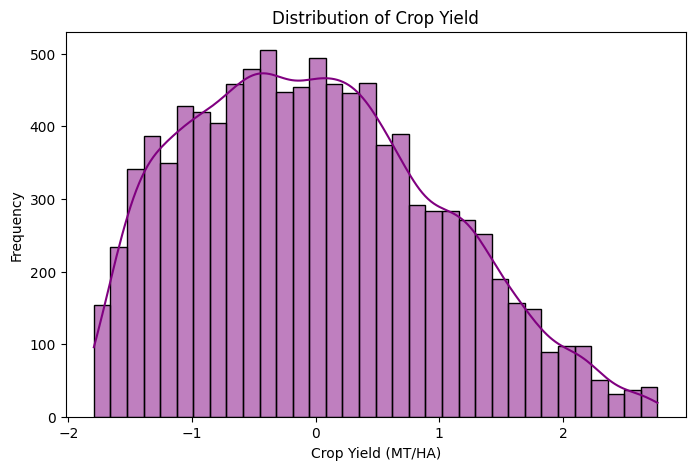

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df["Crop_Yield_MT_per_HA"], kde=True,color='purple')
plt.title("Distribution of Crop Yield")
plt.xlabel("Crop Yield (MT/HA)")
plt.ylabel("Frequency")
plt.show()

- The crop yield values are distributed across different ranges.

- The histogram helps identify whether the data is normally distributed or skewed.

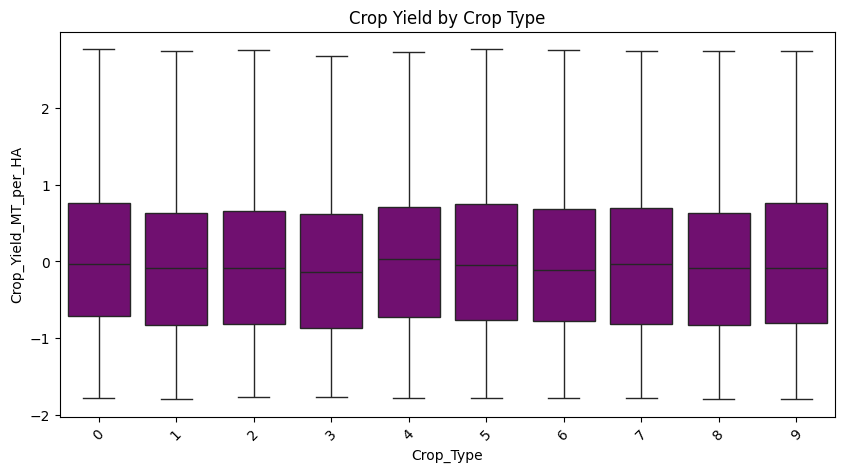

In [46]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Crop_Type",
    y="Crop_Yield_MT_per_HA",
    data=df,
    color='purple'
)

plt.title("Crop Yield by Crop Type")

plt.xticks(rotation=45)

plt.show()

- Different crop types have different yield distributions.

- The boxplot helps identify median values, spread, and outliers.

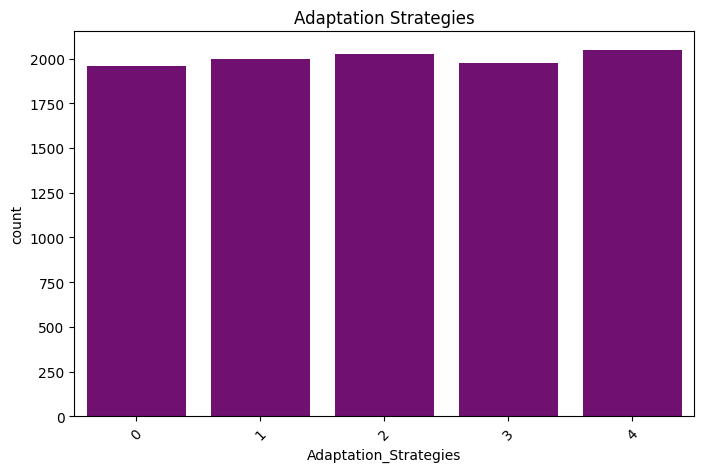

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Adaptation_Strategies",
    data=df,
    color='purple'
)

plt.title("Adaptation Strategies")

plt.xticks(rotation=45)

plt.show()

- This chart shows the frequency of each adaptation strategy adopted by farmers.

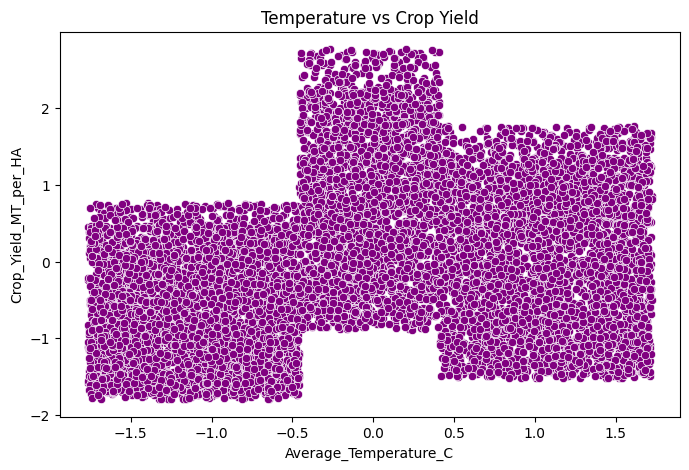

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Average_Temperature_C",
    y="Crop_Yield_MT_per_HA",
    data=df,
    color='purple'
)

plt.title("Temperature vs Crop Yield")

plt.show()

- The scatter plot helps determine whether temperature influences crop yield.

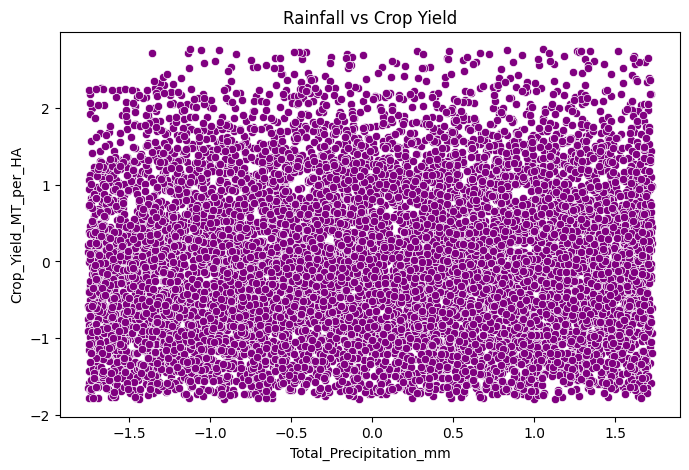

In [49]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Total_Precipitation_mm",
    y="Crop_Yield_MT_per_HA",
    data=df,
    color='purple'
)

plt.title("Rainfall vs Crop Yield")

plt.show()

- Rainfall is an important factor affecting agricultural productivity.

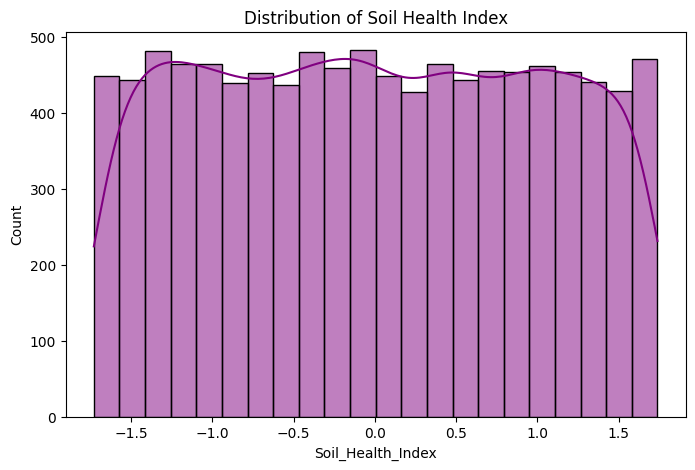

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Soil_Health_Index"],
    kde=True,
    color='purple'
)

plt.title("Distribution of Soil Health Index")

plt.show()

- This plot shows how soil health values are distributed across the dataset.

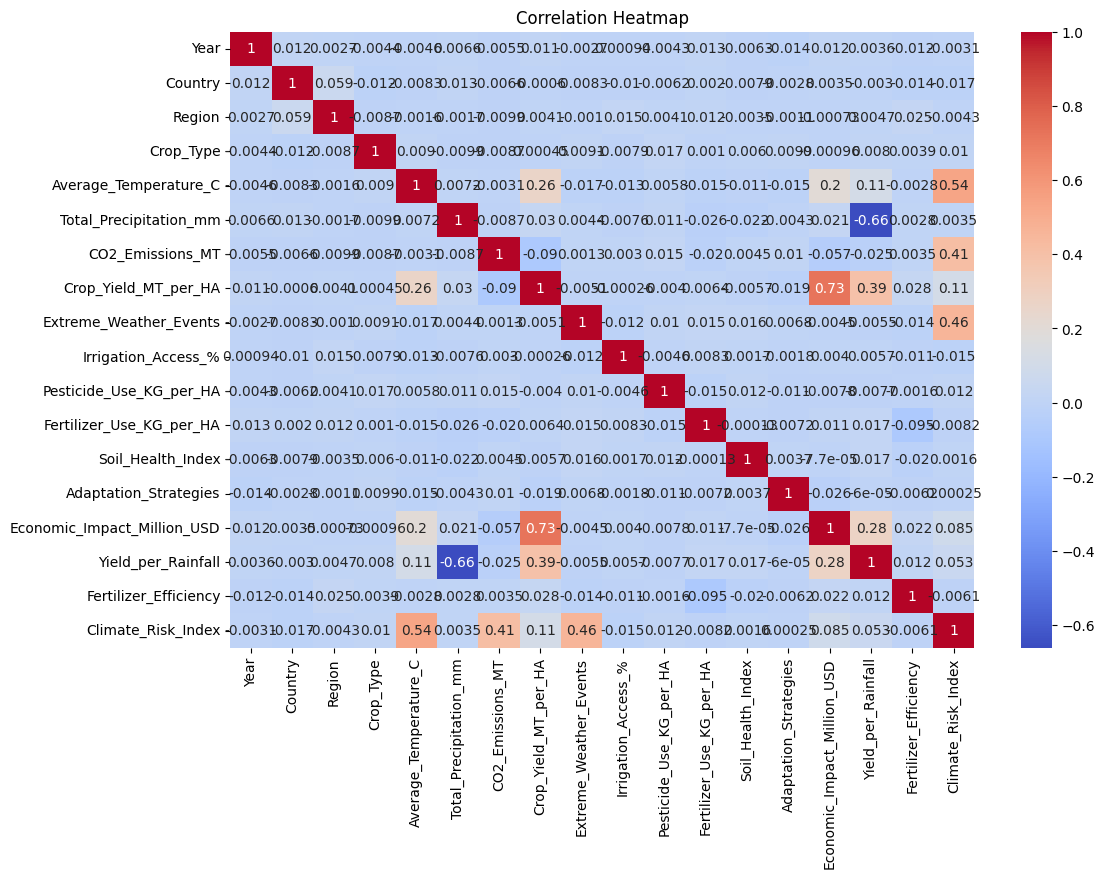

In [53]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

- The heatmap displays positive and negative correlations among numerical features.

- Darker colors indicate stronger relationships.

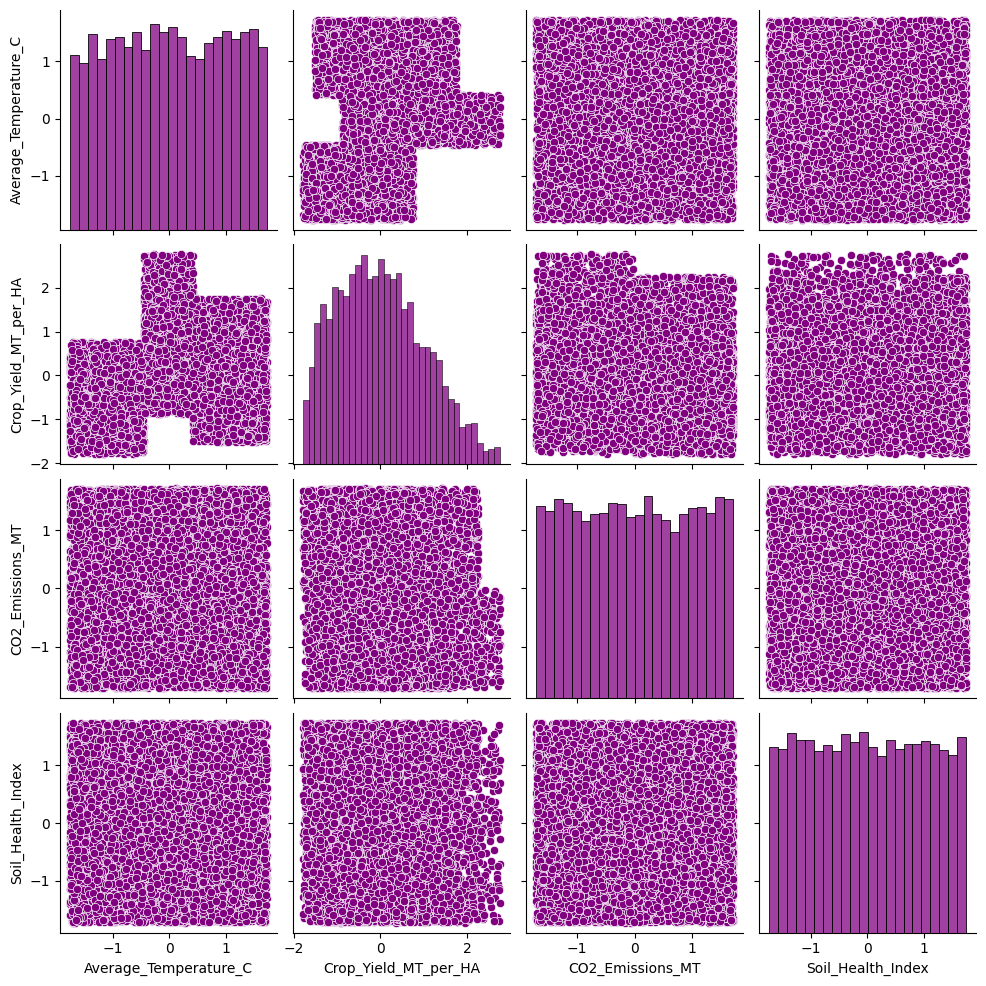

In [54]:
sns.pairplot(
    df[
        [
            "Average_Temperature_C",
            "Crop_Yield_MT_per_HA",
            "CO2_Emissions_MT",
            "Soil_Health_Index"
        ]
    ],
     plot_kws={"color": "purple"},
    diag_kws={"color": "purple"}
)

plt.show()

- The pair plot helps compare relationships and distributions between multiple numerical variables simultaneously.

###Feature Scaling

Feature scaling standardizes numerical columns so they are on a similar scale. This improves the performance of many machine learning algorithms.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "Average_Temperature_C",
    "Total_Precipitation_mm",
    "CO2_Emissions_MT",
    "Crop_Yield_MT_per_HA",
    "Extreme_Weather_Events",
    "Irrigation_Access_%",
    "Pesticide_Use_KG_per_HA",
    "Fertilizer_Use_KG_per_HA",
    "Soil_Health_Index",
    "Economic_Impact_Million_USD",
    "Yield_per_Rainfall",
    "Fertilizer_Efficiency",
    "Climate_Risk_Index"
]

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,2001,India,West Bengal,Corn,-1.194038,-1.446755,-0.003098,-0.503878,0.953706,-1.566488,-1.026604,-1.225852,0.908583,Water Management,0.322889,0.837420,-0.027961,-0.601780
1,2024,China,North,Corn,-1.047523,1.617322,1.696752,-0.503878,0.953706,-1.700786,0.559291,-0.930829,-0.538814,Crop Rotation,-0.140024,-0.701175,-0.043590,-0.236551
2,2001,France,Ile-de-France,Wheat,0.511818,-0.385010,1.222890,-0.521909,0.006034,1.122548,0.169374,0.541850,0.142547,Water Management,0.295946,-0.362338,-0.061288,0.985876
3,2001,Canada,Prairies,Coffee,1.099623,-0.568096,-0.155619,1.652807,0.006034,1.493503,-0.729852,1.309886,1.311656,No Adaptation,0.279929,0.596260,-0.054649,0.495650
4,1998,India,Tamil Nadu,Sugarcane,-1.138223,0.019648,-0.400118,-1.162002,1.269597,1.558535,1.338437,1.327302,-0.757186,Crop Rotation,-0.657426,-0.669635,-0.066388,-0.574130


###Encoding Categorical Variables

Machine learning algorithms cannot directly process text values. Therefore, categorical features are converted into numerical values using Label Encoding.

In [39]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "Country",
    "Region",
    "Crop_Type",
    "Adaptation_Strategies"
]

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD,Yield_per_Rainfall,Fertilizer_Efficiency,Climate_Risk_Index
0,2001,6,32,2,-1.194038,-1.446755,-0.003098,-0.503878,0.953706,-1.566488,-1.026604,-1.225852,0.908583,4,0.322889,0.837420,-0.027961,-0.601780
1,2024,4,8,2,-1.047523,1.617322,1.696752,-0.503878,0.953706,-1.700786,0.559291,-0.930829,-0.538814,0,-0.140024,-0.701175,-0.043590,-0.236551
2,2001,5,4,9,0.511818,-0.385010,1.222890,-0.521909,0.006034,1.122548,0.169374,0.541850,0.142547,4,0.295946,-0.362338,-0.061288,0.985876
3,2001,3,18,1,1.099623,-0.568096,-0.155619,1.652807,0.006034,1.493503,-0.729852,1.309886,1.311656,2,0.279929,0.596260,-0.054649,0.495650
4,1998,6,28,7,-1.138223,0.019648,-0.400118,-1.162002,1.269597,1.558535,1.338437,1.327302,-0.757186,0,-0.657426,-0.669635,-0.066388,-0.574130


- Categorical variables have been converted into numerical labels using LabelEncoder.

- This makes the dataset suitable for machine learning models.

###Insights

1. Crop yield is influenced by multiple environmental and agricultural factors such as rainfall, temperature, soil health, irrigation access, fertilizer use, and pesticide use.

2. Regions experience different climate conditions, which directly affect agricultural productivity.

3. Countries with better irrigation access generally achieve more stable crop production.

4. Healthy soil contributes to better crop yield and sustainable farming practices.

5. Extreme weather events increase agricultural losses and negatively affect economic outcomes.

6. Appropriate fertilizer application improves crop yield, whereas excessive use may reduce soil quality over time.

7. Climate change indicators such as temperature and CO₂ emissions are closely related to agricultural sustainability.

8. Feature engineering created meaningful variables like Yield per Rainfall, Fertilizer Efficiency, and Climate Risk Index, providing deeper insights into agricultural performance.

9. Feature scaling standardized numerical values, making them suitable for machine learning algorithms.

10. Label Encoding converted categorical variables into numerical values, allowing them to be used in predictive models.

11. Data visualization helped identify trends, distributions, correlations, and potential outliers.

12. The dataset demonstrates the importance of sustainable farming practices and climate adaptation strategies for improving agricultural productivity.